In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [18]:
def vectFunc(max_features=1000, ngram_range=(1,2), stop_words='english',min_df=3,max_df=0.8):
    vectorizer = TfidfVectorizer(
        max_features=max_features,  # 500 words/phrases (Standard = 5000, may change)
        ngram_range=ngram_range,  # Consider both singular and pair words
        stop_words=stop_words, # remove common words (Such as in/and)
        min_df=min_df, #At least 3 documents must have this word/phrase
        max_df=max_df # Ignore words that appear in 80% of documents (too common)
    )
    return vectorizer

Finalized_Dataset = pd.read_csv("Datasets/Finalized_Dataset.csv")

# Check the first few rows to make sure the 'not defined' warning can be ignored, and the actual dataset is imported correctly.
print(Finalized_Dataset['content'].head())

vectorizer = vectFunc()

X_tfidf = vectorizer.fit_transform(Finalized_Dataset['content'])

#make sure shape and num of features are the same for each developer:
 #   Shape: 432,1000
 #Features: 1000
print("\nShape of TF-IDF matrix:", X_tfidf.shape)
print("Number of features:", len(vectorizer.vocabulary_))

0    Collision between a car and a motorbike in Żur...
1    Car-motorcycle traffic accident Yesterday, at ...
2    Car-motorcycle collision in Ħal Qormi Today, a...
3    Collision between motorcycle and car in Għaxaq...
4    Car-motorcycle collision Yesterday, at around ...
Name: content, dtype: object

Shape of TF-IDF matrix: (432, 1000)
Number of features: 1000


# Linear Regression

Linear Regression is a supervised learning technique that models the relationship between input features and a target variable using a linear function of the form $f(x)=w^T x+b$ [1]. Where:

- $w$ is the weight vector.
- $b$ is the bias.
- $x$ represents the input features.

Its objective is to learn a weight vector and intercept that best fit the training data by minimizing prediction error, most commonly through the Least Squares method. This method reduces the squared difference between predicted values and actual targets across all training samples. While effective for many numerical prediction tasks, Linear Regression struggles in high-dimensional domains such as text classification, where the number of features often exceeds the number of training samples. In such cases, the underlying matrix can become singular, leading to non-unique solutions and a high risk of overfitting [1,2]. 

## Linear Regression in use with TF-IDF

Linear regression and its variants are commonly used alongside TF-IDF to enable predictive modeling and classification on textual data. Since regression models require numerical input, TF-IDF acts as the feature extraction step by transforming unstructured text into high-dimensional numerical vectors that represent the importance of words within documents [1,2]. These TF-IDF values become the predictor variables for the linear model. The regression algorithm then learns a weight vector and intercept, multiplying each TF-IDF feature by a learned weight and combining them to produce an output. In this way, the model effectively learns how influential each word is in determining an outcome, such as linear regression being to conduct sentiment analysis on film reviews [3] or Twitter posts [4].

As mentioned in the EDA the following features were deemed unfit for Linear regression and were removed: `'precipitation_sum','precipitation_hours', 'is_holiday'`. Tests were conducted and the MSE and R² scores yielded better results when the features where removed (due to the left-skew nature of the feautres, not fit for Linear Regression).

In [31]:

y = Finalized_Dataset['severity_label'] # Specify the target variable 

# Features (all except severity)
X = Finalized_Dataset.drop(columns=['severity_label', 'precipitation_sum','precipitation_hours', 'is_holiday'])


text_column = 'content'
numeric_columns = X.drop(columns=[text_column]).columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('text', vectFunc(), text_column),
        ('num', StandardScaler(), numeric_columns)
    ]
)

# Pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)
y_pred_rounded = np.round(y_pred).astype(int)

### Evaluation

The evaluation will be carried out using a combination of quantitative metrics, visual inspection, and class-level analysis to provide a comprehensive understanding of the model’s performance. First, standard regression metrics such as **Mean Squared Error (MSE)** and **$R^2$** score will be used to assess how closely the predicted values align with the true target values and how well the model explains variance in the data. These metrics should offer an objective measure of overall predictive accuracy.

Next, a visual comparison of actual versus predicted values will be performed with the use of a scatter plot. By plotting the predictions against true values, alongside a reference line representing perfect prediction; it should be allow intuitive inspection of model behavior.

Finally, the continuous predictions will be rounded and constrained to valid class boundaries to enable classification-style evaluation. The number of correct and incorrect predictions will then be calculated, followed by the construction of a confusion matrix. This provides detailed insight into how well each class is predicted and highlights misclassification patterns.

In [20]:
# Evaluate

print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 0.7854152586851355
R²: 0.33607235950549597


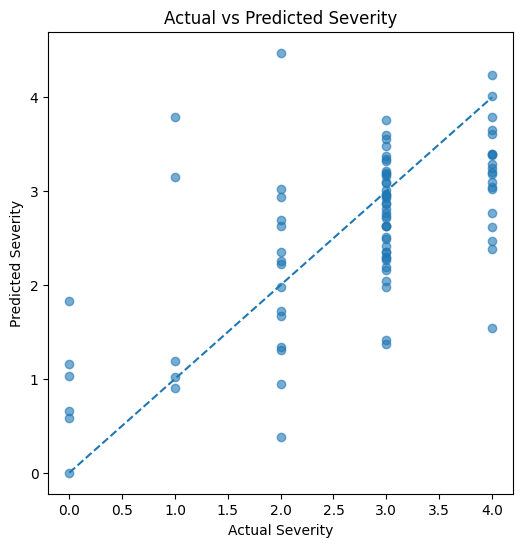

In [21]:
# Visualization: Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel("Actual Severity")
plt.ylabel("Predicted Severity")
plt.title("Actual vs Predicted Severity")
plt.show()

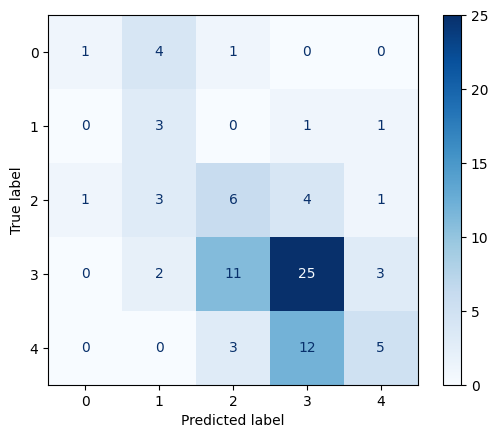

In [22]:
y_pred_rounded = np.clip(
    np.round(y_pred),
    y_test.min(),
    y_test.max()
).astype(int)

cm = confusion_matrix(y_test, y_pred_rounded)

labels = sorted(y_test.unique())

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap="Blues", values_format="d")
plt.show()

conf_matrix = pd.DataFrame(
    cm,
    index=[f"Actual {l}" for l in labels],
    columns=[f"Predicted {l}" for l in labels]
)

In [23]:
correct = np.sum(y_pred_rounded == y_test)
incorrect = np.sum(y_pred_rounded != y_test)


print({
    "Correct predictions": correct,
    "Incorrect predictions": incorrect
})

{'Correct predictions': np.int64(40), 'Incorrect predictions': np.int64(47)}


# Ridge Linear Regression (L2-Regularized Regression)

Ridge Linear Regression extends standard Linear Regression by introducing regularization to improve model stability and generalization. It modifies the original least squares objective by adding a penalty term proportional to the squared magnitude of the weights (L2 regularization), controlled by a regularization parameter $𝜆$. This penalty discourages overly complex models by shrinking coefficient values, ensuring the solution matrix remains non-singular and thus guaranteeing a unique solution when $𝜆>0$. Ridge Regression is computationally efficient and has proven effective in scenarios with many features or imbalanced datasets, particularly when positive examples are rare. However, because it still relies on squared loss, it remains sensitive to outliers and may penalize confidently correct predictions [1,2].

The key difference between Linear Regression and Ridge Linear Regression lies in how they handle model complexity and overfitting, particularly in high-dimensional settings such as text classification. Standard Linear Regression focuses solely on minimizing training error, which can lead to unstable or overly complex models when using sparse representations like TF-IDF, where the number of features often exceeds the number of training samples [2]. Ridge Regression addresses this limitation by introducing a regularization term that penalizes large weights, trading a small increase in bias for a substantial reduction in variance, ensuring a unique and more robust solution with improved generalization. While both methods are mathematically simple and efficient. Ridge Regression is generally more reliable in real-world machine learning applications [1], especially in text-based and imbalanced classification problems. In practice, classification-oriented variants such as Ridge Classifiers are preferred, as they effectively map TF-IDF-weighted inputs to class probabilities or decision boundaries, combining structured textual representations with a stable linear modeling framework for accurate predictions [2].

In [24]:
# ---- pipeline (use Ridge instead of LinearRegression) ----
ridge_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", Ridge(random_state=42))
])

# ---- split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Hyper-parameter tuning

Hyperparameter tuning is performed using GridSearchCV to systematically identify the optimal configuration for both the TF-IDF feature extraction stage and the Ridge regression model. A grid of candidate values is defined for key TF-IDF parameters: 

- maximum vocabulary size,
- n-gram range,
- document frequency thresholds,
- and term frequency. 

In parallel, multiple values of the Ridge regularization parameter $(α)$ are tested to balance model complexity and generalization.

In [25]:
# ---- hyperparameter grid ----
param_grid = {
    # TF-IDF params (inside ColumnTransformer -> "text" transformer)
    "preprocessing__text__max_features": [1000, 3000, 8000],
    "preprocessing__text__ngram_range": [(1,1), (1,2)],
    "preprocessing__text__min_df": [1, 3, 5],
    "preprocessing__text__max_df": [0.8, 0.9, 0.95],
    "preprocessing__text__sublinear_tf": [True, False],

    # Ridge regularization strength
    "regressor__alpha": [0.1, 1.0, 10.0, 50.0, 100.0],
}

# ---- grid search ----
gs = GridSearchCV(
    ridge_pipe,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",  # good default for regression
    cv=5,
    n_jobs=-1,
    verbose=1
)

gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Best CV MSE:", -gs.best_score_)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Best params: {'preprocessing__text__max_df': 0.8, 'preprocessing__text__max_features': 1000, 'preprocessing__text__min_df': 3, 'preprocessing__text__ngram_range': (1, 2), 'preprocessing__text__sublinear_tf': True, 'regressor__alpha': 0.1}
Best CV MSE: 0.7809507153817511


### Evualuate 

MSE: 0.6082202085010028
R²: 0.48585897273351697


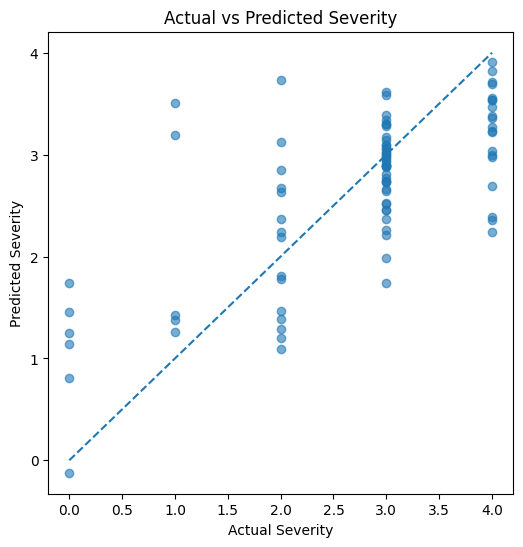

In [26]:
# ---- evaluate best model on held-out test set ----
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

# Visualization: Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel("Actual Severity")
plt.ylabel("Predicted Severity")
plt.title("Actual vs Predicted Severity")
plt.show()

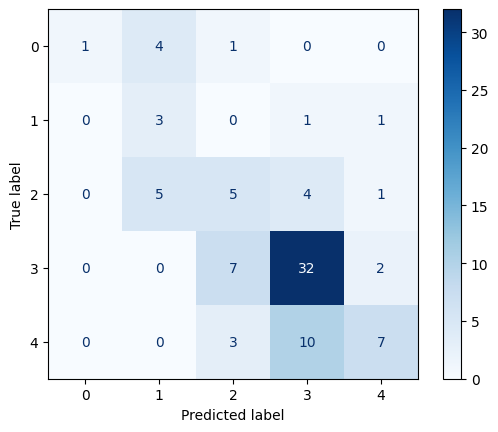

In [ ]:
y_pred_rounded = np.clip(
    np.round(y_pred),
    y_test.min(),
    y_test.max()
).astype(int)

cm = confusion_matrix(y_test, y_pred_rounded)

labels = sorted(y_test.unique())

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap="Blues", values_format="d")
plt.show()

conf_matrix = pd.DataFrame(
    cm,
    index=[f"Actual {l}" for l in labels],
    columns=[f"Predicted {l}" for l in labels]
)

In [30]:
correct = np.sum(y_pred_rounded == y_test)
incorrect = np.sum(y_pred_rounded != y_test)


print({
    "Correct predictions": correct,
    "Incorrect predictions": incorrect
})

{'Correct predictions': np.int64(48), 'Incorrect predictions': np.int64(39)}


# Results

Ridge Regression clearly outperformed standard Linear Regression across both quantitative metrics and class-level prediction behavior, as evidenced by the reported results and confusion matrices. From a regression standpoint, Ridge achieved a lower Mean Squared Error (0.61 vs 0.79) and a higher $R^2$ score (0.49 vs 0.34), indicating that it not only made more accurate predictions on average but also explained a substantially larger proportion of the variance in severity levels. This improvement reflects Ridge Regression’s ability to control model complexity through regularization, preventing overly large coefficients that can arise in high-dimensional TF-IDF feature spaces.

The confusion matrices further reinforce this conclusion. Ridge Regression shows a stronger concentration of predictions along the diagonal, particularly for mid-to-high severity classes (levels 3 and 4), meaning it more frequently predicts the correct severity level. In contrast, Linear Regression exhibits greater dispersion, with more predictions spilling into neighboring severity classes, especially underestimating or overestimating mid-range severities. This indicates that Ridge produces more stable and consistent decision boundaries, reducing noise-driven errors. Overall, the regularization in Ridge Regression enables better generalization on sparse, high-dimensional text features, leading to both improved numerical performance and more reliable class-level predictions compared to standard Linear Regression.

# Limitations of Linear Regression 

Despite the improvement, several limitations remain. First, the $R²$ score, while higher for Ridge Regression, is still below 0.5, indicating that a significant portion of variance in severity is not fully explained by the model. Second, both models show confusion between adjacent severity levels, suggesting that linear decision boundaries may struggle to capture nuanced differences in ordinal or subjective labels. Finally, the reliance on TF-IDF means that semantic relationships between words are not captured linearly, limiting the model’s ability to understand context, which is an issue that could be addressed with more expressive representations such as word embeddings or transformer-based models.

# Bias and Ethical Considerations

Several ethical considerations and sources of bias arise from the dataset and modeling approach used in this study. First, the imbalanced distribution of severity labels, with a strong skew toward levels 3–4, introduces class imbalance bias. From a machine learning perspective, this can cause the model to prioritize majority classes while underperforming on minority severity levels, leading to misleadingly strong overall metrics. This bias can be partially mitigated through techniques such as stratified sampling, class weighting, resampling methods, or the use of evaluation metrics that are more sensitive to imbalance (e.g., macro-averaged scores rather than accuracy alone).

Second, feature-selection bias is introduced during exploratory data analysis when specific keywords or injury-related terms are implicitly associated with severity levels. While EDA is useful for understanding the data, relying on manually identified words to guide severity labeling risks embedding subjective assumptions into the model. This can result in a circular learning process, where the model simply reinforces pre-defined interpretations rather than discovering genuine patterns. To address this, severity labeling should be grounded in objective criteria or expert annotation, and feature learning should rely on automated, data-driven processes rather than human-selected indicators.

Finally, the limited domain and small dataset size pose significant risks to fairness and generalizability. TF-IDF is highly sensitive to corpus-specific language usage, meaning that dominant reporting styles, terminology, or phrasing within a narrow domain can disproportionately influence feature weights. As a result, the model may perform well on similar data but fail when exposed to different writing styles or contexts. From a basic ML standpoint, this limitation can be addressed by expanding the dataset across multiple sources, increasing linguistic diversity, and validating the model on external datasets. Without these safeguards, conclusions drawn from the model should be treated as exploratory rather than universally applicable.

# References

[1] J. Zhang and Y. Yang, “Robustness of regularized linear classification methods in text categorization,” in Proceedings of the 26th Annual International ACM SIGIR Conference on Research and Development in Information Retrieval (SIGIR ’03), Toronto, Canada, 2003, pp. 190–197, doi: 10.1145/860435.860471.

[2] N. A. Azeez, S. Misra, D. O. Ogaraku, and A. P. Abidoye, “A predictive model for benchmarking the performance of algorithms for fake and counterfeit news classification in global networks,” Sensors, vol. 24, no. 17, Art. no. 5817, 2024, doi: 10.3390/s24175817.

[3] D. S. Ramdan, R. D. Apnena, and C. A. Sugianto, "Film Review Sentiment Analysis: Comparison of Logistic Regression and Support Vector Classification Performance Based on TF-IDF," Journal of Applied Intelligent System, vol. 8, no. 3, pp. 341–352, Nov. 2023.

[4] Imamah and F. H. Rachman, "Twitter Sentiment Analysis of Covid-19 Using Term Weighting TF-IDF And Logistic Regresion," in 2020 Information Technology International Seminar (ITIS), Surabaya, Indonesia, 2020, pp. 238-242.

[5] L. L. Johnson, C. B. Borkowf, and P. A. Shaw, “Hypothesis testing,” in Principles and Practice of Clinical Research, 4th ed., J. I. Gallin, F. P. Ognibene, and L. L. Johnson, Eds. Boston, MA, USA: Academic Press, 2018, pp. 341–357, doi: 10.1016/B978-0-12-849905-4.00024-1.